In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

   # Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load the data (now it's in the same folder)
df = pd.read_csv(r'C:\Users\Slim 5pro 9LIN\Downloads\visual studio\customer-churn-project\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv')


   # Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check data types and info
print("Dataset Information:")
print("="*50)
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [4]:
# Check for missing values
print("Missing Values:")
print("="*50)
print(df.isnull().sum())
print("\n")

# Basic statistics for numerical columns  
print("Basic Statistics:")
print("="*50)
df.describe()

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Basic Statistics:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


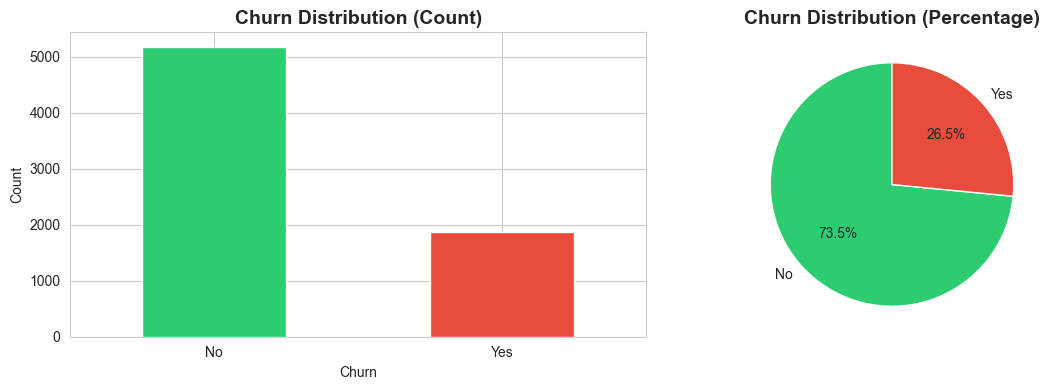


⚠️ Overall Churn Rate: 26.54%


In [5]:
# Analyze Churn distribution
print("Churn Distribution:")
print("="*50)
print(df['Churn'].value_counts())
print("\n")
print(df['Churn'].value_counts(normalize=True) * 100)

# Visualize churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

# Pie chart
df['Churn'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                 colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Calculate churn rate
churn_rate = df['Churn'].value_counts(normalize=True)['Yes'] * 100
print(f"\n⚠️ Overall Churn Rate: {churn_rate:.2f}%")

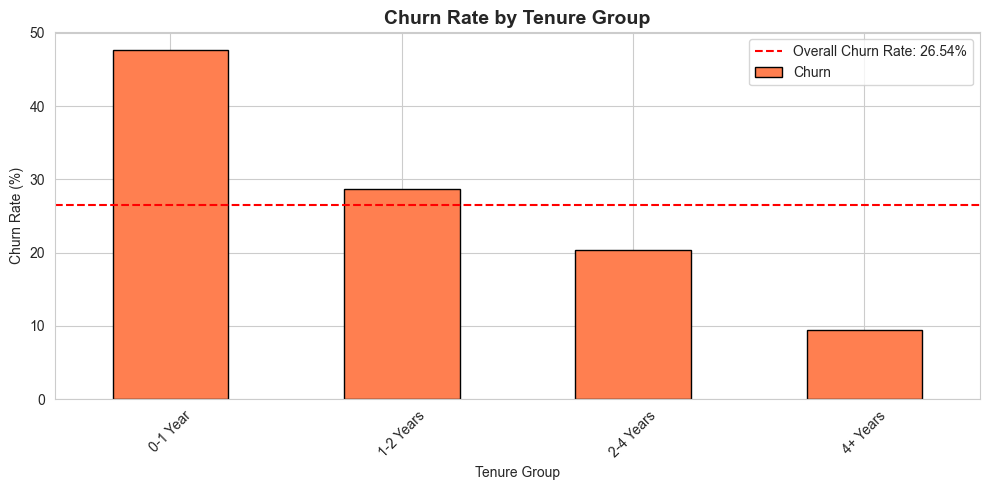


Churn Rate by Tenure Group:
tenure_group
0-1 Year     47.678161
1-2 Years    28.710938
2-4 Years    20.388959
4+ Years      9.513176
Name: Churn, dtype: float64


In [6]:
# Create tenure groups
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], 
                             labels=['0-1 Year', '1-2 Years', '2-4 Years', '4+ Years'])

# Calculate churn rate by tenure group
churn_by_tenure = df.groupby('tenure_group')['Churn'].apply(lambda x: (x=='Yes').sum() / len(x) * 100)

# Visualize
plt.figure(figsize=(10, 5))
churn_by_tenure.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Churn Rate by Tenure Group', fontsize=14, fontweight='bold')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.axhline(y=26.54, color='red', linestyle='--', label='Overall Churn Rate: 26.54%')
plt.legend()
plt.tight_layout()
plt.show()

print("\nChurn Rate by Tenure Group:")
print(churn_by_tenure)

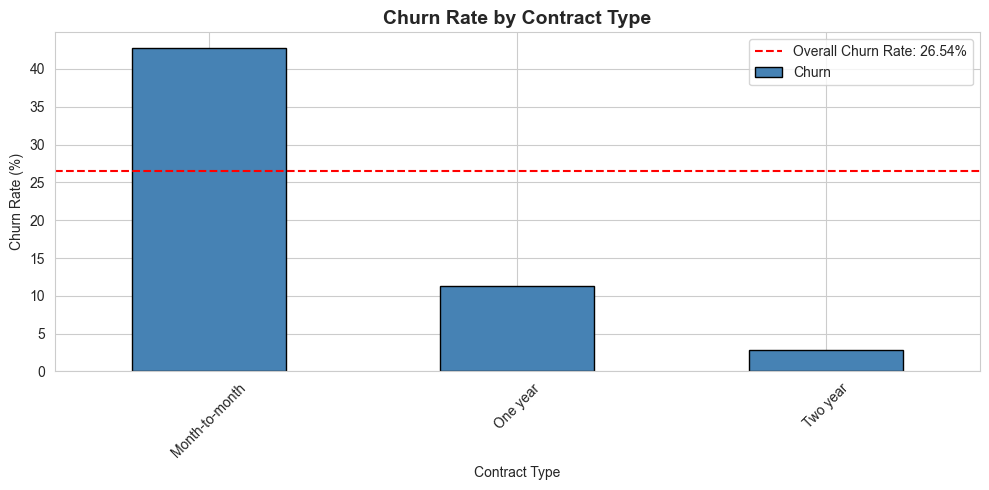


Churn Rate by Contract Type:
Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


In [7]:
# Calculate churn rate by contract type
churn_by_contract = df.groupby('Contract')['Churn'].apply(lambda x: (x=='Yes').sum() / len(x) * 100).sort_values(ascending=False)

# Visualize
plt.figure(figsize=(10, 5))
churn_by_contract.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.axhline(y=26.54, color='red', linestyle='--', label='Overall Churn Rate: 26.54%')
plt.legend()
plt.tight_layout()
plt.show()

print("\nChurn Rate by Contract Type:")
print(churn_by_contract)

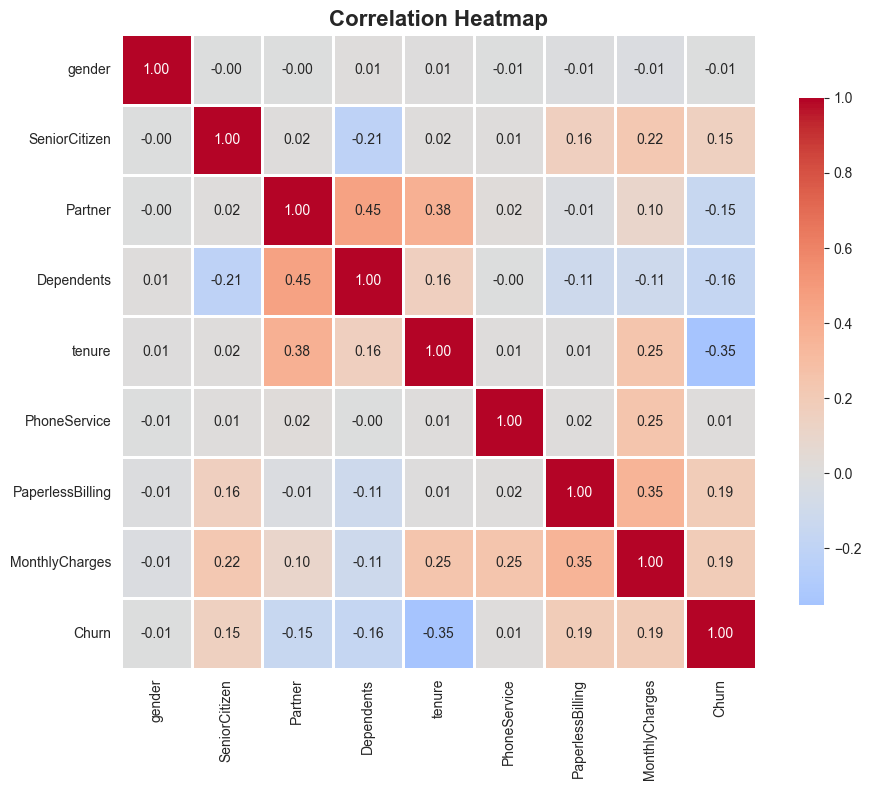


Features Most Correlated with Churn:
Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PhoneService        0.011942
gender             -0.008612
Partner            -0.150448
Dependents         -0.164221
tenure             -0.352229
Name: Churn, dtype: float64


In [8]:
# Prepare data for correlation
df_corr = df.copy()

# Convert binary categorical variables to numeric
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    if col in df_corr.columns:
        df_corr[col] = df_corr[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

# Select only numeric columns
numeric_df = df_corr.select_dtypes(include=[np.number])

# Create correlation matrix
plt.figure(figsize=(10, 8))
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Features most correlated with Churn
print("\nFeatures Most Correlated with Churn:")
print("="*50)
print(correlation['Churn'].sort_values(ascending=False))

## Key Findings from Initial Exploration

### Dataset Overview
- Total customers: 7,043
- Features: 21 columns
- Overall Churn Rate: **26.54%**

### Critical Insights

#### 1. Tenure is Key
- New customers (0-1 year): **47.68% churn** ⚠️ HIGHEST RISK
- Loyal customers (4+ years): **9.51% churn** ✅ Very stable
- **Action:** Focus retention efforts on first-year customers

#### 2. Contract Type Matters Hugely
- Month-to-month: **42.71% churn** ⚠️ MAJOR PROBLEM
- One year: **11.27% churn**
- Two year: **2.83% churn** ✅ Best retention
- **Action:** Incentivize longer contracts

#### 3. Price Sensitivity
- Higher MonthlyCharges correlate with more churn
- **Action:** Review pricing strategy for at-risk segments

### Next Steps
1. Clean data (handle missing values in TotalCharges)
2. Feature engineering (create RFM-like metrics)
3. Customer segmentation using clustering
4. Build churn prediction model
5. Develop targeted retention strategies